# 02 - Acoustic Forward
Generate synthetic observed Marmousi gathers with Deepwave (default) or FD fallback.

In [ ]:
from pathlib import Path
import sys
import numpy as np

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'src').exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.io import load_yaml, seed_everything, get_device, resolve_path
from src.data import load_marmousi_vp
from src.forward import build_surface_acquisition, generate_observed_data
from src.utils.viz import plot_velocity_model, plot_gather

CONFIG_FILE = 'marmousi_acoustic.yaml'
cfg = load_yaml(PROJECT_ROOT / 'configs' / CONFIG_FILE)
seed_everything(int(cfg['seed']))
device = get_device(cfg.get('device', 'auto'))
print('Device:', device)

Device: cuda


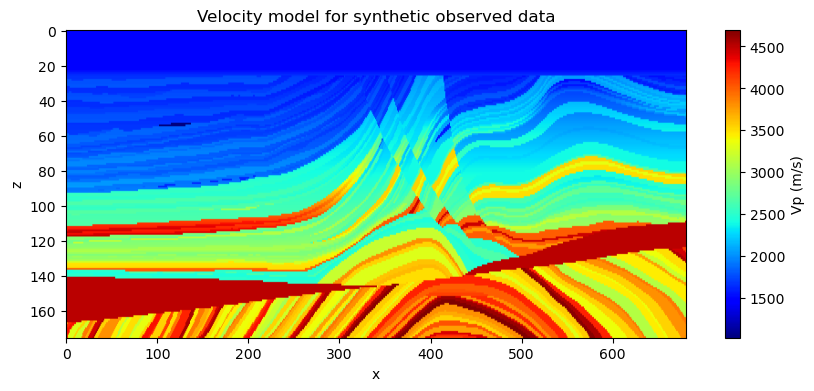

Saved geometry: /root/FWI/pinn_acoustic_fwi/data/synthetic/acquisition_geometry.npz


In [ ]:
vp = load_marmousi_vp(
    resolve_path(PROJECT_ROOT, cfg['data']['vp_path']),
    subsample=int(cfg['model']['subsample'])
)
plot_velocity_model(vp, title='Velocity model for synthetic observed data')

acq = cfg['acquisition']
geom = build_surface_acquisition(
    nx=vp.shape[1],
    nz=vp.shape[0],
    n_shots=int(acq['n_shots']),
    nt=int(acq['nt']),
    dt=float(acq['dt']),
    src_depth_idx=int(acq.get('src_depth_idx', 2)),
    rec_depth_idx=int(acq.get('rec_depth_idx', 2)),
    pad_x=int(acq.get('pad_x', 4)),
    receiver_stride=int(acq.get('receiver_stride', 1)),
)

geom_path = PROJECT_ROOT / cfg['data']['geometry_path']
geom.save(geom_path)
print('Saved geometry:', geom_path)

GPUassert: CUDA driver version is insufficient for CUDA runtime version /project/src/deepwave/scalar.cu 566


Observed data shape [shot,time,receiver]: (8, 1000, 169)
Saved observed: /root/FWI/pinn_acoustic_fwi/data/synthetic/observed_acoustic.npy


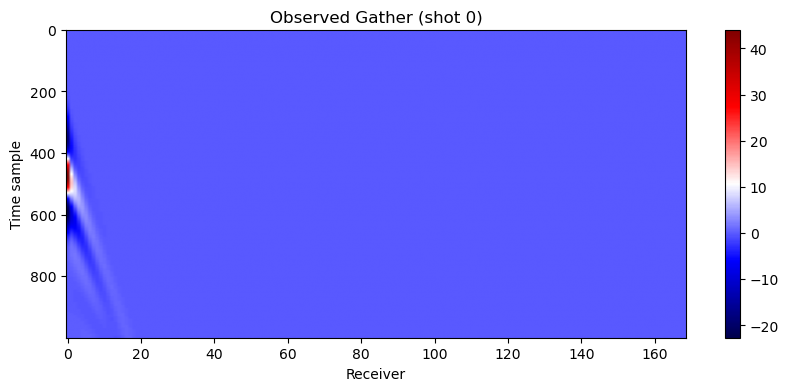

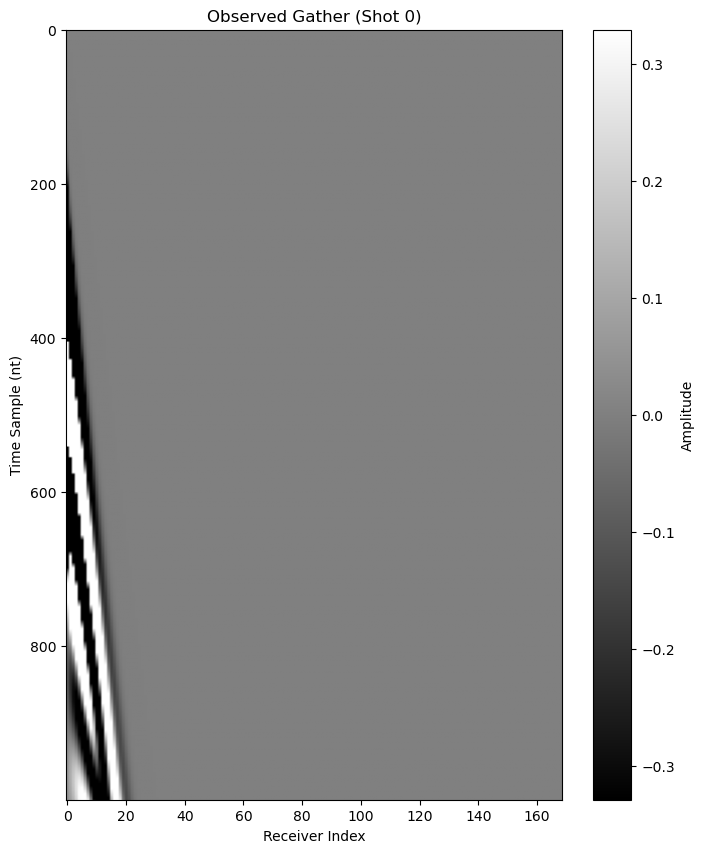

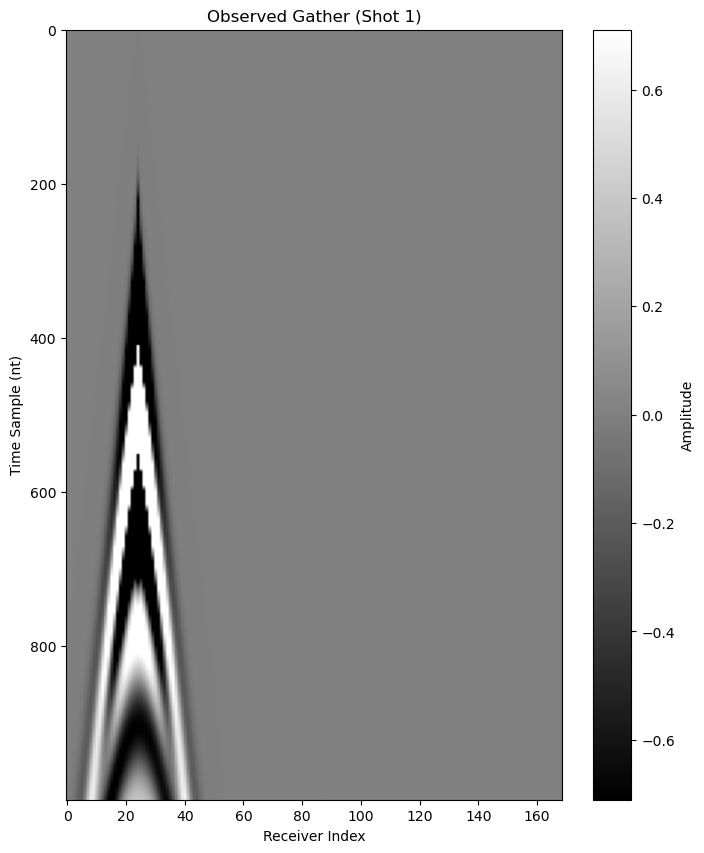

In [ ]:
obs_path = PROJECT_ROOT / cfg['data']['observed_path']
observed = generate_observed_data(
    vp=vp,
    geom=geom,
    dh=float(acq['dh']),
    f_peak=float(acq['f_peak']),
    output_path=obs_path,
    backend=str(acq.get('backend', 'deepwave')),
    device=device,
)
print('Observed data shape [shot,time,receiver]:', observed.shape)
print('Saved observed:', obs_path)
plot_gather(observed[0], title='Observed Gather (shot 0)')
# 2. FIXED Visualization logic using Matplotlib directly
import matplotlib.pyplot as plt

def plot_with_gain(data, title="Shot Gather"):
    # Convert to CPU/Numpy if it's a torch tensor
    if hasattr(data, "cpu"):
        data = data.detach().cpu().numpy()
        
    # Calculate the scale based on the data intensity
    vmax = np.percentile(np.abs(data), 98) 
    
    if vmax == 0:
        print(f"WARNING: {title} is all zeros! Check your acquisition time (nt).")
        return
    
    plt.figure(figsize=(8, 10))
    # We use vmin/vmax to "clip" the data manually for better visibility
    plt.imshow(data, aspect='auto', cmap='gray', vmin=-vmax*0.5, vmax=vmax*0.5)
    plt.colorbar(label='Amplitude')
    plt.title(title)
    plt.xlabel('Receiver Index')
    plt.ylabel('Time Sample (nt)')
    plt.show()

# Visualize Shot 0 and Shot 1
for i in range(min(2, observed.shape[0])): 
    plot_with_gain(observed[i], title=f'Observed Gather (Shot {i})')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved data
obs_path = "/root/FWI/pinn_fwi-main/pinn_acoustic_fwi/data/synthetic/observed_acoustic.npy"
data = np.load(obs_path)

# Check for stability
if np.any(np.isnan(data)):
    print("❌ Still exploding! Decrease dt further in your yaml file.")
else:
    print(f"✅ Data is stable. Shape: {data.shape}")
    
    # Use a high-gain plot to see the waves
    vmax = np.percentile(np.abs(data[0]), 98)
    plt.figure(figsize=(10, 6))
    plt.imshow(data[0], aspect='auto', cmap='gray', vmin=-vmax*0.2, vmax=vmax*0.2)
    plt.title("Shot 0 - Stabilized and Gained")
    plt.colorbar()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/root/FWI/pinn_fwi-main/pinn_acoustic_fwi/data/synthetic/observed_acoustic.npy'

✅ Simulation successful. Data is stable.


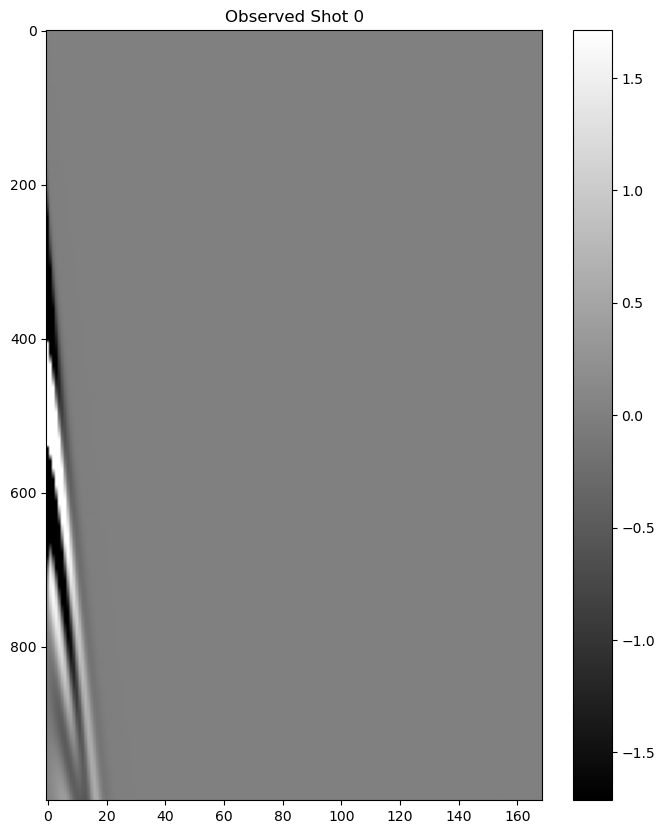

In [ ]:
# ... (after generate_observed_data call)

# Check for NaNs or Infinities
if np.any(np.isnan(observed)) or np.any(np.isinf(observed)):
    print("❌ ERROR: Simulation exploded! Your 'dt' is too large for your 'dh'.")
    print("Action: Go to your config and decrease 'dt' (try 0.0004).")
else:
    print("✅ Simulation successful. Data is stable.")
    
    import matplotlib.pyplot as plt
    
    def plot_stable_gather(data, title="Shot Gather"):
        if hasattr(data, "cpu"): data = data.detach().cpu().numpy()
        
        # Use a robust scaler to avoid being blinded by outliers
        vmax = np.nanpercentile(np.abs(data), 99) 
        plt.figure(figsize=(8, 10))
        plt.imshow(data, aspect='auto', cmap='gray', vmin=-vmax, vmax=vmax)
        plt.title(title)
        plt.colorbar()
        plt.show()

    plot_stable_gather(observed[0], title="Observed Shot 0")